# Notebook 2 — Training a Computer Vision Model to Classify Pneumonia
### AIMI High School Internship

Given a chest X-ray, can a model tell whether the patient shows signs of **pneumonia**? Fast, accurate detection matters clinically — especially in the ER and ICU, where it speeds up treatment.

We frame this as a **binary classification** task:
> *Does this X-ray show pneumonia (`Target = 1`) or not (`Target = 0`)?*

Chest X-rays with labels, split into `train` / `val` / `test`. Positive cases also include a bounding box around the affected region (we'll use boxes for *detection* in a later notebook — here we only classify). The full dataset is prepared and explored in the **Dataset Setup** notebook, so here we'll just peek at a few images before training.

[**AUROC**](https://glassboxmedicine.com/2019/02/23/measuring-performance-auc-auroc/) — ranges from 0.5 (random) to 1.0 (perfect). We care most about **Val AUC**: performance on images the model never trained on.

## What you'll do in this notebook

1. **Setup** — one cell installs and loads everything.
2. **Dataset Visualization** — look at a few X-rays, their boxes, and the label balance.
3. **Baseline (Supervised Fine-Tuning)** — build a pretrained ResNet-18 step by step, train it once, and read its AUC.
4. **Ablations** — change *one* thing at a time (backbone, augmentation, learning rate…) and log whether Val AUC went up or down.
5. **Zero-Shot Classification (BiomedCLIP)** — classify with *no training at all*, just by describing each class in words, and compare it to your trained model.


# 1. Setup

> Before running: **Runtime → Change runtime type → T4 GPU**, then make sure the dataset is in your Drive (see the Dataset Setup notebook).

Run the cell below once. It mounts Drive and then **copies the data onto Colab's local disk** — this matters: reading thousands of images directly off Google Drive during training is extremely slow, while the local disk is fast.

In [ ]:
#@title Notebook settings { display-mode: "form" }
from pathlib import Path
# Put `dataset_1.zip` in your Google Drive ("My Drive"), then run all cells.
DATA_DIR = Path("/content/drive/MyDrive/dataset_1")


In [ ]:
#@title Run setup (imports · data · device) { display-mode: "form" }
import os
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm                       # progress bars

# Mount Google Drive so we can read the dataset (skipped automatically off Colab).
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

# Unzip the dataset to Colab's local disk and read from there. Reading images over the Drive
# mount re-fetches each file from the network on every read (slow); we unzip the dataset's
# .zip once to /content instead. Students put dataset_1.zip / dataset_2.zip in their Drive
# (My Drive). Skipped when DATA_DIR already points at local data (validation / off-Colab).
import zipfile
DATA_DIR = Path(DATA_DIR)
if str(DATA_DIR).startswith("/content/drive/"):
    local = Path("/content") / DATA_DIR.name
    if not local.exists():
        zip_path = Path("/content/drive/MyDrive") / f"{DATA_DIR.name}.zip"
        assert zip_path.exists(), (
            f"{zip_path} not found — add {DATA_DIR.name}.zip to your Google Drive (My Drive).")
        print(f"Unzipping {DATA_DIR.name}.zip to local disk (one-time)...")
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(local)                            # everything lands under /content/<name>
        kids = [p for p in local.iterdir() if not p.name.startswith((".", "__"))]
        if len(kids) == 1 and kids[0].is_dir():            # zip wrapped files in one extra folder
            import shutil
            for it in list(kids[0].iterdir()):
                shutil.move(str(it), str(local / it.name))
            kids[0].rmdir()
    DATA_DIR = local
assert DATA_DIR.exists(), f"dataset not found at {DATA_DIR}."
print("Training data is at:", DATA_DIR)

TRAIN_DIR = DATA_DIR / "train_images"
VAL_DIR   = DATA_DIR / "val_images"

# Each row: patientId, Target (0/1), class, and x/y/width/height for positives.
# Positive patients have ONE ROW PER BOUNDING BOX, so for a *classification* task
# we keep one row per patient (one image = one example).
train_df = pd.read_csv(DATA_DIR / "train_labels.csv").drop_duplicates("patientId").reset_index(drop=True)
val_df   = pd.read_csv(DATA_DIR / "val_labels.csv").drop_duplicates("patientId").reset_index(drop=True)

EPOCHS = 5

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Ready. device={device} | train={len(train_df)} | val={len(val_df)} | epochs={EPOCHS}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training data is at: /content/dataset_1
Ready. device=cuda | train=3000 | val=1500 | epochs=5


# 2. Dataset Visualization

You've already explored this data, so we'll keep it quick: one helper to view an X-ray (with its pneumonia box), a slider to browse, and a histogram of the labels.

In [2]:
# Show one X-ray; draw a red box around the pneumonia region for positive cases.
def plot_one_image(df, img_dir, idx):
    row = df.iloc[idx]
    img = cv2.cvtColor(cv2.imread(str(img_dir / f"{row['patientId']}.jpg")), cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    # Only positives have a box (x, y, width, height)
    if row["Target"] == 1 and not pd.isna(row.get("x", np.nan)):
        x, y, w, h = int(row["x"]), int(row["y"]), int(row["width"]), int(row["height"])
        plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", lw=2))
    plt.title(f"Target = {row['Target']}  (1 = pneumonia, 0 = normal)")
    plt.axis("off"); plt.show()

In [3]:
#@title Browse the X-rays { run: "auto", display-mode: "form" }
#@markdown Drag the slider. Red box = pneumonia region (positive cases only).
image_id = 51 #@param {type:"slider", min:0, max:240, step:1}
plot_one_image(train_df, TRAIN_DIR, image_id)

NameError: name 'train_df' is not defined

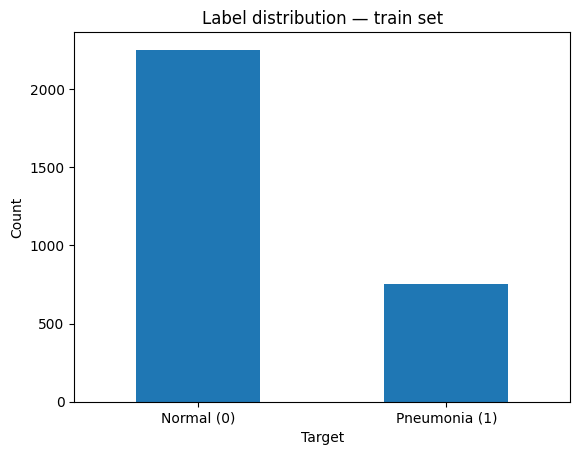

In [ ]:
# How balanced are the classes? Imbalance (many more 0s than 1s) can quietly hurt training.
train_df["Target"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Normal (0)", "Pneumonia (1)"], rotation=0)
plt.ylabel("Count"); plt.title("Label distribution — train set"); plt.show()

# 3. Baseline — Supervised Fine-Tuning (SFT)

We won't train a model from scratch — that needs millions of images. Instead we take **ResNet-18**, a network already trained on a huge collection of everyday images, and *fine-tune* it on our X-rays. It already knows how to detect edges, textures, and shapes; we just teach it what those patterns mean for pneumonia. This reuse is called **transfer learning**.

> 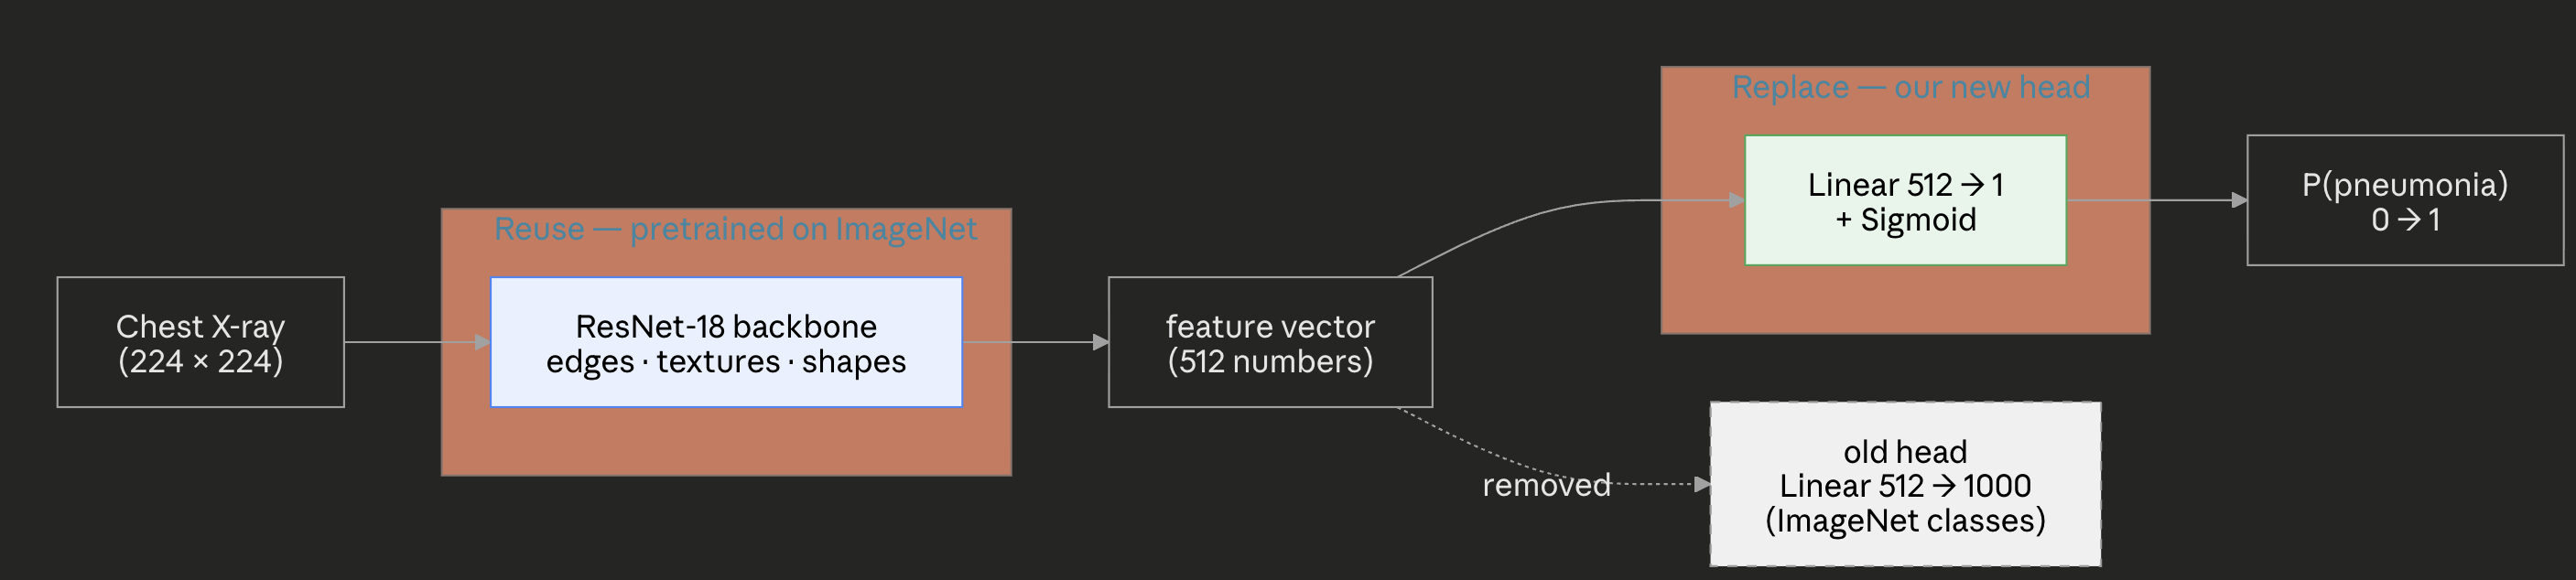

simple transfer-learning diagram (pretrained backbone → "frozen knowledge" → new task-specific head which in our case is classification).

We'll build this in small pieces (3.1–3.6), then run it (3.7). Each piece is wrapped in a function so that in Part 4 you can re-run a whole experiment in one line.

## 3.1 Preprocessing the images (transforms)

A model can't eat a raw JPEG — it needs a fixed-size grid of numbers. A **transform** is a recipe that converts each image into that form:

- **Resize → 224×224**: ResNet expects one fixed input size.
- **ToTensor**: turn the pixels (0–255) into a **tensor** — *a tensor is just a grid of numbers (here, floats between 0 and 1) that the GPU can do fast math on.*
- **Normalize**: shift the colors onto the same scale ResNet saw during pretraining (those mean/std numbers are the ImageNet statistics) — this makes fine-tuning learn faster.

 [torchvision transforms docs](https://docs.pytorch.org/vision/main/transforms.html)

In [ ]:
# Baseline preprocessing recipe applied to every image.
transform = transforms.Compose([
    transforms.Resize((224, 224)),                       # fixed input size
    transforms.ToTensor(),                               # image -> tensor (grid of numbers) in [0, 1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],     # ImageNet mean...
                         std=[0.229, 0.224, 0.225]),     # ...and std
])

## 3.2 Feeding data to the model (Dataset + DataLoader)

PyTorch needs a standard way to fetch one example at a time. A **Dataset** answers two questions: *how many images are there?* (`__len__`) and *give me image #i and its label* (`__getitem__`). A **DataLoader** then wraps the Dataset to do two practical jobs: group examples into **batches** (a **batch** = a small handful of images, here 32, processed together for speed) and **shuffle** the training data each epoch (so the model can't just memorize the order).

 [Datasets & DataLoaders tutorial](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html)

In [ ]:
class PneumoniaDataset(Dataset):
    """Knows how to return (image_tensor, label) for one patient."""
    def __init__(self, df, img_dir, transform=None):
        self.df, self.img_dir, self.transform = df, img_dir, transform

    def __len__(self):
        return len(self.df)                            # total number of images

    def __getitem__(self, idx):
        row = self.df.iloc[idx]                        # pick row idx
        img = Image.open(self.img_dir / f"{row['patientId']}.jpg").convert("RGB")
        if self.transform:
            img = self.transform(img)                  # apply the 3.1 recipe
        return img, int(row["Target"])                 # (image, 0 or 1)

# Helper so we can rebuild loaders later with a different transform (used in Part 4).
def make_loaders(transform, batch_size=32):
    train_ds = PneumoniaDataset(train_df, TRAIN_DIR, transform)
    val_ds   = PneumoniaDataset(val_df,   VAL_DIR,   transform)
    # num_workers>0 reads several images in parallel; persistent_workers keeps
    # them alive between epochs (avoids re-spawning)
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                       num_workers=2, pin_memory=True, persistent_workers=True),
            DataLoader(val_ds,   batch_size=batch_size,
                       num_workers=2, pin_memory=True, persistent_workers=True))

## 3.3 The model (ResNet-18 + a new head)

A ResNet has two parts: a **backbone** that turns an image into a list of numbers describing it (a "feature vector"), and a **head** that maps those numbers to an answer. The pretrained head predicts 1000 everyday-object classes — useless to us — so we **replace the head** with a single output. A `Sigmoid` squashes that output to a probability between 0 and 1: *P(pneumonia)*.

*(When we say a model's **weights**, we mean the millions of numbers inside it that get tuned during training — "pretrained weights" are ones already learned from other images.)*

Different model families name their head differently (`.fc`, `.classifier`, `.head`), so the helper handles each.

 [ResNet paper](https://arxiv.org/abs/1512.03385) · [all torchvision models + weights](https://docs.pytorch.org/vision/main/models.html#table-of-all-available-classification-weights)

> 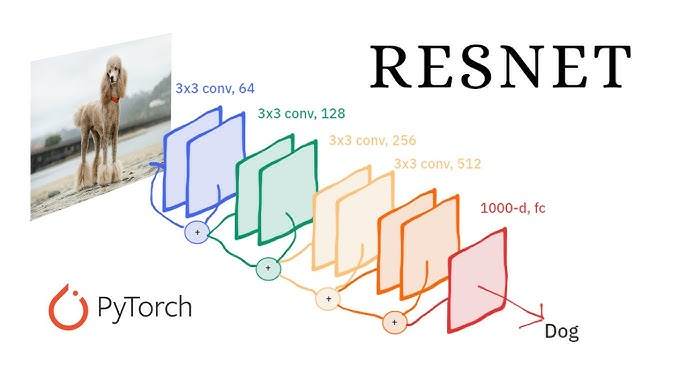

a high-level ResNet block diagram (image → stacked conv blocks → feature vector → head)

In [ ]:
# Build a pretrained backbone, then swap its head for a single sigmoid output = P(pneumonia).
def make_model(backbone="resnet18"):
    if backbone in ("resnet18", "resnet34", "resnet50"):
        m = getattr(models, backbone)(weights="DEFAULT")     # load pretrained weights
        # The pretrained head predicts 1000 ImageNet classes. Replace it with a
        # single output + Sigmoid so the model returns P(pneumonia) in [0, 1].
        # TODO: replace m.fc with nn.Sequential(nn.Linear(in_features -> 1), nn.Sigmoid()).
        # Hint: the number of input features is m.fc.in_features.
        m.fc = nn.Sequential(nn.Linear(m.fc.in_features, 1), nn.Sigmoid())
    elif backbone == "densenet121":
        m = models.densenet121(weights="DEFAULT")
        m.classifier = nn.Sequential(nn.Linear(m.classifier.in_features, 1), nn.Sigmoid())
    elif backbone == "swin_v2_b":
        m = models.swin_v2_b(weights="DEFAULT")
        m.head = nn.Sequential(nn.Linear(m.head.in_features, 1), nn.Sigmoid())
    elif backbone == "maxvit_t":
        m = models.maxvit_t(weights="DEFAULT")
        in_f = m.classifier[-1].in_features
        m.classifier[-1] = nn.Sequential(nn.Linear(in_f, 1), nn.Sigmoid())
    else:
        raise ValueError(f"Unknown backbone: {backbone}")
    return m.to(device)                                      # move model onto the GPU

## 3.4 How the model learns (one training step)

Learning is a loop. For each batch the model makes a guess, we measure how wrong it was, and we nudge its weights to be a little less wrong next time. Two pieces drive this:

- **Loss function** = *how wrong* a guess is. For yes/no problems we use **Binary Cross-Entropy** (`BCELoss`): confident-and-correct → tiny loss; confident-and-wrong → huge loss.
- **Optimizer** = *how to adjust* the weights. We use **Adam**; its **learning rate** sets how big each adjustment is.

*Jargon check: a **gradient** is an arrow telling each weight which way (and how much) to move to lower the loss. **Backpropagation** ("backprop") is the math that computes all those arrows in one pass.*

Every training step is the same five moves — read the comments below.

 [Optimization loop tutorial](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Run through all training batches once."""
    model.train()                              # training mode
    total = 0.0
    pbar = tqdm(loader, desc="  training", leave=False)   # live progress bar
    for images, labels in pbar:                # one batch at a time
        images = images.to(device)
        labels = labels.float().to(device)
        # The same five moves every training step makes:
        # TODO: fill in the five moves of one training step.
        # 1. FORWARD pass: preds = model(images).squeeze(1)
        # 2. loss = criterion(preds, labels)
        # 3. optimizer.zero_grad()   # clear last step's gradients
        # 4. loss.backward()         # backprop
        # 5. optimizer.step()        # update the weights
        preds = model(images).squeeze(1)
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.3f}")   # show running loss each batch
    return total / len(loader)                 # average loss this epoch

## 3.5 Measuring performance (evaluation)

To grade the model we turn off learning (`eval` mode, no gradients — this is faster and makes sure grading doesn't change the weights), collect its probabilities on a dataset, and compute **AUROC**. We do this on both train and val: if **Train AUC is high but Val AUC is low**, the model is *memorizing* rather than *learning* — that's **overfitting**.

*(`max_batches` lets us score on just a sample of batches — we use it for the quick per-epoch train check so each epoch stays fast; the val score always uses the full set.)*

In [ ]:
@torch.no_grad()                               # no gradients = faster, and no learning happens
def evaluate(model, loader, max_batches=None):
    model.eval()                               # evaluation mode
    probs, labels_all = [], []
    for i, (images, labels) in enumerate(tqdm(loader, desc="  evaluating", leave=False)):
        # Collect the model's probability for every image, plus the true labels.
        # TODO: run the model on this batch and accumulate predictions + labels.
        # out = model(images.to(device)).squeeze(1)
        # probs.extend(out.cpu().numpy()); labels_all.extend(labels.numpy())

        images = images.to(device)
        labels = labels.float().to(device)
        out = model(images).squeeze(1)
        probs.extend(out.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

        if max_batches and i + 1 >= max_batches:   # optional: stop early to save time
            break
    probs, labels_all = np.array(probs), np.array(labels_all)
    acc = ((probs > 0.5) == labels_all).mean()                          # accuracy (for reference)
    auc = roc_auc_score(labels_all, probs) if len(set(labels_all)) > 1 else float("nan")
    return acc, auc, probs, labels_all

## 3.6 Putting it together

We've now built **every ingredient** training needs:

- a **transform** (3.1) to turn each image into numbers,
- a **Dataset + DataLoader** (3.2) to serve those images in batches,
- a **model** (3.3) that outputs *P(pneumonia)*,
- a **training step** (3.4) that learns from one batch, and
- an **evaluation** function (3.5) that scores the model with AUROC.

`run_training` below just **wires these together**. For each epoch it does the same routine: train once, then check the score on train and on val. It returns the final scores and the validation predictions (used in 3.7). Remember: one **epoch** = one full pass over all the training images. While it runs you'll see a **live progress bar** (training, then evaluating) so you can tell it's working.

In [ ]:
def run_training(model, train_loader, val_loader, lr=1e-4, epochs=2):
    # The two things that drive learning (from 3.4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)   # how to adjust weights
    criterion = nn.BCELoss()                                  # how wrong a guess is

    train_auc = val_auc = 0.0
    for epoch in range(epochs):                 # one loop = one epoch = one full pass over the data

        # ---- STEP 1: TRAIN on every batch (this is where weights actually change) ----
        loss = train_one_epoch(model, train_loader, optimizer, criterion)

        # ---- STEP 2: EVALUATE on the training set (sampled = a few batches, for speed) ----
        _, train_auc, _, _ = evaluate(model, train_loader, max_batches=15)

        # ---- STEP 3: EVALUATE on the validation set (the score we trust: unseen data) ----
        _, val_auc, val_probs, val_labels = evaluate(model, val_loader)

        # ---- STEP 4: REPORT this epoch's numbers ----
        print(f"epoch {epoch+1:2d} | loss {loss:.3f} | train AUC {train_auc:.3f} | val AUC {val_auc:.3f}")

    return train_auc, val_auc, val_probs, val_labels

## 3.7 Run the baseline

Now actually train it: ResNet-18, no augmentation, `lr=1e-4`, 5 epochs. Watch the AUC climb, and **write the final Val AUC down** — it's the number every experiment in Part 4 compares against.

In [ ]:
train_loader, val_loader = make_loaders(transform)
base_model = make_model("resnet18")
base_train_auc, base_val_auc, val_probs, val_labels = run_training(
    base_model, train_loader, val_loader, lr=1e-4, epochs=EPOCHS)
print(f"\nBASELINE Val AUC = {base_val_auc:.3f}  (write this down for Part 4)")


  training:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

epoch  1 | loss 0.434 | train AUC 0.969 | val AUC 0.834


  training:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

epoch  2 | loss 0.233 | train AUC 0.999 | val AUC 0.820


  training:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

epoch  3 | loss 0.073 | train AUC 1.000 | val AUC 0.806


  training:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

epoch  4 | loss 0.045 | train AUC 1.000 | val AUC 0.826


  training:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

epoch  5 | loss 0.028 | train AUC 1.000 | val AUC 0.815

BASELINE Val AUC = 0.815  (write this down for Part 4)


In [ ]:
train_loader, val_loader = make_loaders(transform)
base_model = make_model("resnet18")
base_train_auc, base_val_auc, val_probs, val_labels = run_training(
    base_model, train_loader, val_loader, lr=1e-4, epochs=EPOCHS)
print(f"\nBASELINE Val AUC = {base_val_auc:.3f}  (write this down for Part 4)")

AUC is a single number — it won't show you *where* the model struggles. Slide through a few validation images and compare the prediction to the truth.

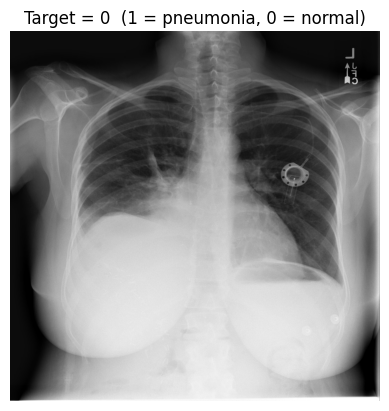

prediction: P(pneumonia)=0.000 -> NORMAL
true label: 0


In [ ]:
#@title Inspect a baseline prediction { run: "auto", display-mode: "form" }
#@markdown Compare the model's predicted probability to the true label.
image_id = 88 #@param {type:"slider", min:0, max:240, step:1}
plot_one_image(val_df, VAL_DIR, image_id)
p = val_probs[image_id]
print(f"prediction: P(pneumonia)={p:.3f} -> {'PNEUMONIA' if p > 0.5 else 'NORMAL'}")
print(f"true label: {int(val_labels[image_id])}")

# 4. Ablations — make the baseline better

The baseline isn't great. Now you experiment. The rule of good experiments: **change ONE thing, re-run, compare to baseline, log it.** Then change it back before trying the next idea — otherwise you won't know which change caused what.

Each knob below is a **one-line change** thanks to the functions in Part 3:

- **Backbone** — pass a different name to `make_model`. Bigger ≈ smarter but slower.
  `run_training(make_model("resnet50"), train_loader, val_loader)`
  Wired up: `"resnet34"`, `"resnet50"`, `"densenet121"`, `"swin_v2_b"`, `"maxvit_t"`. [More models](https://docs.pytorch.org/vision/main/models.html#table-of-all-available-classification-weights).

- **Learning rate** — change the `lr` argument.
  `run_training(make_model("resnet18"), train_loader, val_loader, lr=1e-3)`
  Try `1e-5`, `1e-3`, `1e-2`.

- **Epochs** — change the `epochs` argument.
  `run_training(make_model("resnet18"), train_loader, val_loader, epochs=10)`
  Try `3`, `10`, `15`. Watch the train–val gap grow = overfitting.

- **Data augmentation** — needs a new transform + new loaders, so use the runnable example below. [transforms docs](https://docs.pytorch.org/vision/main/transforms.html). *Think:* a flip puts the heart on the wrong side — help or hurt?

- **Class imbalance** *(advanced)* — give the rarer class more weight; edit `run_training` to use a weighted loss, e.g. `nn.BCELoss(weight=...)`, or a weighted sampler.

**Log every run in one table** (Δ = Val AUC minus your baseline):

| Change (one thing) | Val AUC | Δ vs baseline | What I noticed |
|---|---|---|---|
| Baseline (resnet18, no aug, lr 1e-4, 5 ep) |  | 0.000 |  |
|  |  |  |  |
|  |  |  |  |
|  |  |  |  |

Worked example below — the data-augmentation case (the one that takes more than one line).

In [ ]:
# EXAMPLE ABLATION — augmentation: add flip + small rotation, change nothing else.
aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

aug_train_loader, aug_val_loader = make_loaders(aug_transform)
_, aug_val_auc, _, _ = run_training(make_model("resnet18"), aug_train_loader, aug_val_loader)
print(f"\nΔ Val AUC vs baseline: {aug_val_auc - base_val_auc:+.3f}")

  training:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

epoch  1 | loss 0.467 | train AUC 0.835 | val AUC 0.838


  training:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

epoch  2 | loss 0.388 | train AUC 0.885 | val AUC 0.833

Δ Val AUC vs baseline: +0.017


# 5. **[Optional]** Zero-Shot Classification with BiomedCLIP

Everything above needed labeled training data. **CLIP** models learn a shared space for images *and* text, so you can classify by simply describing each class in words — **no training**. **BiomedCLIP** is a CLIP tuned on biomedical images and papers.

*Quick terms: an **embedding** is a list of numbers (a vector) that captures the "meaning" of an image or a sentence — similar things get similar embeddings. We compare two embeddings by how closely they point in the same direction (**cosine similarity**).*

The trick: embed each text prompt and each image into the same space, then pick the prompt whose embedding is most similar to the image.

> cli.svg

CLIP diagram (image encoder + text encoder → shared embedding space, match by similarity)

In [ ]:
#@title Zero-shot setup (install + load BiomedCLIP) { display-mode: "form" }
!pip -q install open_clip_torch
import open_clip

MODEL_ID = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(MODEL_ID)
clip_tokenizer = open_clip.get_tokenizer(MODEL_ID)
clip_model = clip_model.to(device).eval()
print("BiomedCLIP loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00


Exception ignored in: <function tqdm.__del__ at 0x7a9754e46200>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a97558c7880>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1668, in _shutdown_workers
    self._mark_worker_as_unavailable(worker_id, shutdown=True)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1595, in _mark_worker_as_unavailable
    not self._workers_status[worker_i

open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/225k [00:00<?, ?B/s]

BiomedCLIP loaded.


In [ ]:
# Two prompts: whichever is more similar to the image wins. prompts[0] = pneumonia.
prompts = [
    "a chest x-ray showing pneumonia",
    "a normal chest x-ray without pneumonia",
]

@torch.no_grad()
def zero_shot_predict(df, img_dir, prompts):
    # Turn the text prompts into embeddings once (they don't change per image).
    text = clip_tokenizer(prompts).to(device)
    text_feat = clip_model.encode_text(text)
    text_feat /= text_feat.norm(dim=-1, keepdim=True)        # unit length -> cosine similarity

    probs_pneumonia, labels = [], []
    for _, row in df.iterrows():
        img = Image.open(img_dir / f"{row['patientId']}.jpg").convert("RGB")
        img = clip_preprocess(img).unsqueeze(0).to(device)
        img_feat = clip_model.encode_image(img)              # embed the image
        img_feat /= img_feat.norm(dim=-1, keepdim=True)
        prob = (100.0 * img_feat @ text_feat.T).softmax(dim=-1)[0]   # similarity -> probabilities
        probs_pneumonia.append(prob[0].item())               # prob of the "pneumonia" prompt
        labels.append(int(row["Target"]))
    return np.array(probs_pneumonia), np.array(labels)

In [ ]:
zs_probs, zs_labels = zero_shot_predict(val_df, VAL_DIR, prompts)
zs_acc = ((zs_probs > 0.5) == zs_labels).mean()
zs_auc = roc_auc_score(zs_labels, zs_probs)
print(f"Zero-shot   | accuracy {zs_acc:.3f} | AUC {zs_auc:.3f}")
print(f"Trained SFT | Val AUC  {base_val_auc:.3f}  (for comparison)")

Zero-shot   | accuracy 0.699 | AUC 0.845
Trained SFT | Val AUC  0.815  (for comparison)


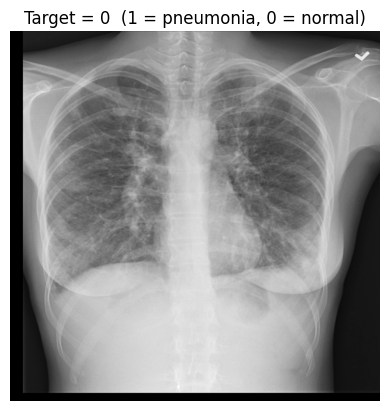

prediction: P(pneumonia)=0.965 -> PNEUMONIA
true label: 0


In [ ]:
#@title Inspect a zero-shot prediction { run: "auto", display-mode: "form" }
image_id = 74 #@param {type:"slider", min:0, max:240, step:1}
plot_one_image(val_df, VAL_DIR, image_id)
p = zs_probs[image_id]
print(f"prediction: P(pneumonia)={p:.3f} -> {'PNEUMONIA' if p > 0.5 else 'NORMAL'}")
print(f"true label: {int(zs_labels[image_id])}")

## Prompt engineering

Zero-shot performance depends heavily on *wording*. Try it: rewrite the two `prompts` to push accuracy higher — be specific and clinical (e.g. *"a frontal chest radiograph with patchy airspace opacities consistent with pneumonia"*).

Try several versions, re-run the two cells above, and log accuracy each time:

| Prompt pair | Accuracy | AUC | Notes |
|---|---|---|---|
| Baseline ("…showing pneumonia" / "…without pneumonia") |  |  |  |
|  |  |  |  |
|  |  |  |  |

*Why might a longer, more clinical description change the result?*